## Section 1 — Load Data

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("data/processed/y_test.csv").squeeze()
X_predict = pd.read_csv("data/processed/X_predict.csv")

print(f"X_train:   {X_train.shape}")
print(f"X_test:    {X_test.shape}")
print(f"X_predict: {X_predict.shape}")

X_train:   (460, 14)
X_test:    (116, 14)
X_predict: (567, 14)


## Section 2 — Define Categorical Features

In [24]:
cat_features = [
    "property_type",
    "neighbourhood",
    "requested_timeline",
    "referral_source",
    "homeowner_status",
    "preferred_contact",
    "lead_capture_weather",
    "customer_age_bracket",
    "lead_weekday",
]

numeric_features = [c for c in X_train.columns if c not in cat_features]

print("Categorical features:")
print(cat_features)
print(f"\nNumeric features:")
print(numeric_features)

Categorical features:
['property_type', 'neighbourhood', 'requested_timeline', 'referral_source', 'homeowner_status', 'preferred_contact', 'lead_capture_weather', 'customer_age_bracket', 'lead_weekday']

Numeric features:
['estimated_job_size_sqft', 'distance_to_queens_km', 'has_pets', 'lead_month_sin', 'lead_month_cos']


## Section 3 — Train CatBoost

In [25]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    eval_metric="Accuracy",
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
)

0:	learn: 0.7391304	test: 0.6982759	best: 0.6982759 (0)	total: 8.98ms	remaining: 4.48s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.775862069
bestIteration = 10

Shrink model to first 11 iterations.


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)

## Section 4 — Evaluate on Test Set

In [26]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc * 100:.1f}%)")
print()
print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))

Accuracy: 0.7759 (77.6%)

              precision    recall  f1-score   support

         Low       0.84      0.75      0.79        36
      Medium       0.80      0.89      0.84        36
        High       0.70      0.70      0.70        44

    accuracy                           0.78       116
   macro avg       0.78      0.78      0.78       116
weighted avg       0.78      0.78      0.78       116



## Section 5 — Confusion Matrix

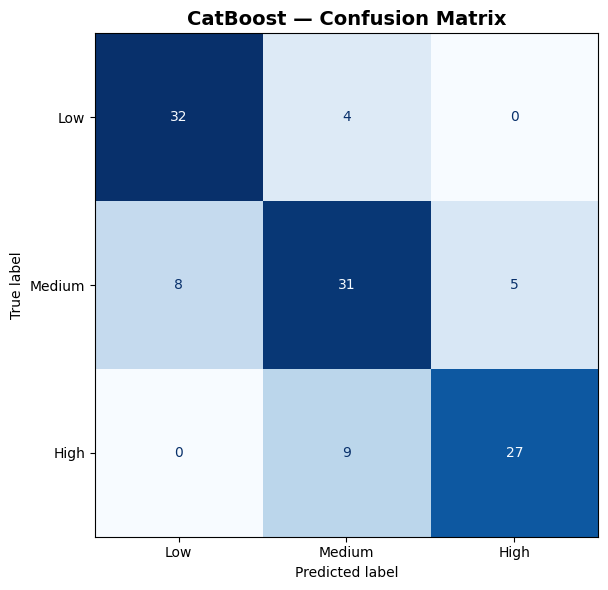

In [27]:
labels = ["Low", "Medium", "High"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", colorbar=False, ax=ax)
ax.set_title("CatBoost \u2014 Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig("figures/08_catboost_confusion_matrix.png", dpi=150)
plt.show()

## Section 6 — Feature Importance

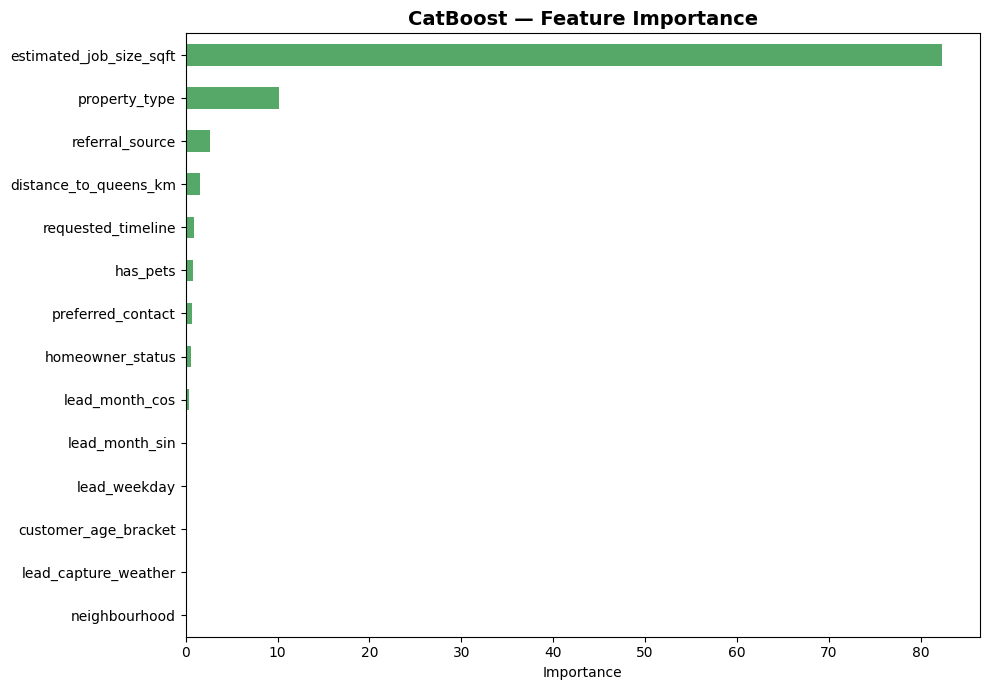


Feature importances (descending):
  estimated_job_size_sqft        82.35
  property_type                  10.12
  referral_source                2.69
  distance_to_queens_km          1.51
  requested_timeline             0.88
  has_pets                       0.84
  preferred_contact              0.68
  homeowner_status               0.57
  lead_month_cos                 0.37
  neighbourhood                  0.00
  lead_capture_weather           0.00
  customer_age_bracket           0.00
  lead_weekday                   0.00
  lead_month_sin                 0.00


In [28]:
importances = model.get_feature_importance()
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot.barh(ax=ax, color="#55A868")
ax.set_title("CatBoost \u2014 Feature Importance", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
fig.savefig("figures/09_catboost_feature_importance.png", dpi=150)
plt.show()

print("\nFeature importances (descending):")
for name, imp in feat_imp.sort_values(ascending=False).items():
    print(f"  {name:30s} {imp:.2f}")

## Section 7 — Predict on Unlabeled Leads

In [29]:
preds = model.predict(X_predict).flatten()
proba = model.predict_proba(X_predict)

results = X_predict.copy()
results["predicted_profit_band"] = preds

for i, cls in enumerate(model.classes_):
    results[f"prob_{cls}"] = proba[:, i]

results.to_csv("catboost_predictions.csv", index=False)
print(f"Saved catboost_predictions.csv ({len(results)} rows)")
print()
print("Predicted profit band distribution:")
print(results["predicted_profit_band"].value_counts())

Saved catboost_predictions.csv (567 rows)

Predicted profit band distribution:
predicted_profit_band
Low       209
Medium    195
High      163
Name: count, dtype: int64
